# Data Preprocessing 1 - Pandas & NumPy Fundamentals

The **pure pandas / NumPy** half of the preprocessing toolkit - the operations you reach for before scikit-learn ever enters the picture: exploring data, handling missing values by hand, removing duplicates, fixing data types, cleaning text, reshaping, and engineering features.

**Dataset:** Titanic (loaded from seaborn - no download needed).

> Continues in **`02_sklearn_preprocessing.ipynb`** (scalers, encoders, pipelines) and **`03_advanced_concepts.ipynb`** (outliers, datetime features, target encoding).

# 0) Setup and Imports

Before running this notebook, make sure all required packages are installed.
Run the following command in your terminal or in a notebook cell:

```
pip install numpy pandas seaborn scikit-learn imbalanced-learn joblib matplotlib
```

> **Note:** `imbalanced-learn` is a separate package from scikit-learn. It must be installed explicitly — it is not included with the standard scikit-learn install.

In [1]:
import numpy as np
# NumPy is used for numerical operations (arrays, math functions, etc.)

# NumPy is used for numerical operations (arrays, math functions, etc.)

import pandas as pd
# Pandas is used to load, inspect, clean, and manipulate tabular datasets (DataFrames)

import seaborn as sns
# Seaborn is used here to load the built-in Titanic dataset with a single line of code
# No file download or Kaggle account required

from sklearn.model_selection import train_test_split
# Used to split the dataset into training and testing sets

from sklearn.impute import SimpleImputer, KNNImputer
# SimpleImputer: fills missing values using mean, median, mode, or constant
# KNNImputer: fills missing values using nearest neighbors (more advanced)

from sklearn.preprocessing import (
    StandardScaler,    # Standardizes features (mean=0, std=1)
    MinMaxScaler,      # Scales features to a fixed range (usually 0 to 1)
    RobustScaler,      # Scales using median and IQR (robust to outliers)
    MaxAbsScaler,      # Scales by maximum absolute value
    Normalizer,        # Normalizes each row to unit length
    LabelEncoder       # Encodes a categorical column into integer labels
)

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# OneHotEncoder: converts categories into binary (0/1) columns
# OrdinalEncoder: converts categories into ordered integer labels

from sklearn.compose import ColumnTransformer
# Applies different preprocessing steps to different column types

from sklearn.pipeline import Pipeline
# Chains preprocessing steps and the ML model into one workflow

from sklearn.linear_model import LinearRegression, LogisticRegression
# LinearRegression: predicts continuous values (e.g., fare)
# LogisticRegression: predicts binary classes (e.g., survived)

from sklearn.feature_selection import VarianceThreshold, RFE
# VarianceThreshold: removes nearly constant (low-variance) features
# RFE: Recursive Feature Elimination — removes least important features step by step

from sklearn.decomposition import PCA, TruncatedSVD
# PCA: reduces dimensionality while keeping maximum information
# TruncatedSVD: similar to PCA, works well on sparse data too

from sklearn.metrics import (
    r2_score,               # Regression: proportion of variance explained
    mean_squared_error,     # Regression: average squared prediction error
    accuracy_score,         # Classification: proportion of correct predictions
    classification_report   # Classification: precision, recall, F1 per class
)

from imblearn.over_sampling import SMOTE
# SMOTE: Synthetic Minority Over-sampling Technique
# Creates synthetic samples for the minority class to fix class imbalance

import joblib
# Saves and loads trained models and preprocessing pipelines
import matplotlib.pyplot as plt
# matplotlib is used for all visualizations throughout the notebook

sns.set_theme(style="whitegrid", palette="muted")
# Apply a clean consistent visual theme to all plots
from sklearn.metrics import confusion_matrix
# Used for building the confusion matrix visualization in Section 20.3


# Dataset Overview: Titanic — Survival Prediction

For this preprocessing demonstration, we use the **Titanic** dataset, built directly into seaborn.

**How to load it:**
```python
df = sns.load_dataset("titanic")
```
No file download, no Kaggle account, no file path — it loads automatically.

---

**About the Dataset**

The Titanic dataset contains information about 891 passengers aboard the RMS Titanic, which sank in April 1912.

**It contains:**
- Numeric features: `age`, `fare`, `sibsp`, `parch`, `pclass`
- Categorical features: `sex`, `embarked`, `who`, `deck`
- Real missing values: `age` (177 missing), `deck` (688 missing), `embarked` (2 missing)
- Apparent duplicates: 107 rows become duplicates after subsetting to our selected columns (they may differ in dropped columns like passenger name or ticket number)
- Binary target: `survived` (0 = did not survive, 1 = survived)

---

**Why We Chose This Dataset**

- Has both **numeric and categorical** columns
- Has **real missing values** — no artificial injection needed
- Has **real class imbalance** (62% vs 38%) — ideal for SMOTE
- Supports **both regression** (predict `fare`) and **classification** (predict `survived`)
- Supports **reshaping, merging, and feature engineering** naturally
- **Zero setup** — one line of code to load

---

**Two Key ML Task Types Used in This Notebook**

- **Regression** — predicting a *continuous number* (e.g., "How much did this passenger pay?"). The answer can be any value like 12.50 or 87.30.
- **Classification** — predicting a *category* (e.g., "Did this passenger survive?"). The answer is one of a fixed set of labels like 0 or 1.


- **Linear Regression** → Predicting `fare` (continuous)
- **Logistic Regression** → Predicting `survived` (binary: 0 or 1)

# 1) Load the Titanic Dataset

We load the dataset directly from seaborn into a pandas DataFrame called `df`.
This is the raw table we will inspect and clean before training any ML models.

In [2]:
# Load Titanic dataset directly from seaborn — no files needed
df = sns.load_dataset("titanic")

# Quick preview
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Note:**

`sns.load_dataset("titanic")` fetches the dataset automatically from seaborn's GitHub repository.

`df.head()` shows the first 5 rows by default. Pass a number to see more:

**e.g.** `df.head(10)` shows the first 10 rows

**What is NaN?**

You will notice some cells in the output show `NaN`. This stands for **Not a Number** — it is how pandas marks a missing or unknown value. For example, many passengers' cabin deck is unknown, so `deck` shows `NaN`. Handling these missing values is one of the most important preprocessing steps, covered in detail in **Section 6**.

# 2) Keep a Subset of Columns

The original dataset has 15 columns. We keep a focused selection that includes both numeric and categorical
features (some with missing values), plus our two target variables.

This makes all preprocessing steps clearer without overwhelming noise from columns we don't need.

In [3]:
cols = [
    "survived",   # Binary classification target (0 = died, 1 = survived)
    "fare",       # Numeric regression target (ticket price paid)
    "pclass",     # Numeric — passenger class (1, 2, or 3) — ordinal in nature
    "age",        # Numeric with 177 missing values
    "sibsp",      # Numeric — siblings/spouses aboard
    "parch",      # Numeric — parents/children aboard
    "sex",        # Categorical — male or female
    "embarked",   # Categorical with 2 missing values — port of embarkation (S, C, Q)
    "who",        # Categorical — man, woman, or child
    "deck",       # Categorical with 688 missing values — cabin deck letter
]

df = df[cols].copy()
# .copy() creates an independent copy — changes here won't affect the original data

# The 'deck' column loads as a pandas category dtype from seaborn.
# Convert to plain string (object) so fillna, str methods, and SimpleImputer all work without errors.
df['deck'] = df['deck'].astype(object)

df.head()

,survived,fare,pclass,age,sibsp,parch,sex,embarked,who,deck
0,0,7.2500,3,22.0,1,0,male,S,man,NaN
1,1,71.2833,1,38.0,1,0,female,C,woman,C
2,1,7.9250,3,26.0,0,0,female,S,woman,NaN
3,1,53.1000,1,35.0,1,0,female,S,woman,C
4,0,8.0500,3,35.0,0,0,male,S,man,NaN


**Note:**

`df[cols].copy()` selects only the columns we want and creates a fresh copy.

Using `.copy()` is important — without it, pandas may show a `SettingWithCopyWarning` when you try
to modify values, because it is uncertain whether you are editing the original or a view of it.

# 3) Verify Target Variables

We will use two different columns as targets:

- **`survived`** — binary (0 or 1), used for **classification**
- **`fare`** — continuous price, used for **regression**

This is a common real-world pattern: the same dataset can serve different ML tasks
depending on which column you choose to predict.

In [4]:
# Both targets are already in the dataset — no need to create them manually

# Check class distribution for the classification target
print("Survived value counts:")
print(df["survived"].value_counts())
print()

# Check distribution of the regression target
print("Fare statistics:")
print(df["fare"].describe().round(2))

df[["fare", "survived"]].head(10)

Survived value counts:
survived
0    549
1    342
Name: count, dtype: int64

Fare statistics:
count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64


,fare,survived
0,7.2500,0
1,71.2833,1
2,7.9250,1
3,53.1000,1
4,8.0500,0
5,8.4583,0
6,51.8625,0
7,21.0750,0
8,11.1333,1
9,30.0708,1


**Note:**

Unlike some datasets where you need to engineer a target variable (e.g., creating a binary column from a threshold),
the Titanic dataset comes with `survived` already as a clean 0/1 column.

Notice the class imbalance: **549 passengers did not survive vs 342 who did**. This ~62/38 split
is a real imbalance that we will address later using **SMOTE**.

# 4) Split Features (X) and Targets (y)

We separate the input columns (features) from the output columns (targets).
The model learns patterns from X to predict y.

- **X** = all input features (everything except the targets)
- **y_reg** = `fare` (what we want to predict in regression)
- **y_clf** = `survived` (what we want to predict in classification)

In [5]:
# Feature matrix: remove both target columns
X = df.drop(columns=["fare", "survived"])

# Regression target: continuous fare price
y_reg = df["fare"]

# Classification target: binary survival outcome
y_clf = df["survived"]

X.head()

,pclass,age,sibsp,parch,sex,embarked,who,deck
0,3,22.0,1,0,male,S,man,NaN
1,1,38.0,1,0,female,C,woman,C
2,3,26.0,0,0,female,S,woman,NaN
3,1,35.0,1,0,female,S,woman,C
4,3,35.0,0,0,male,S,man,NaN


**Note:**

`drop(columns=[...])` removes the specified columns and returns a new DataFrame without them.

- Pass a **list** to remove multiple columns at once
- Pass a **string** to remove one column

After this step, `X` contains only the features the model will use to learn.

### Shared setup: numeric vs categorical columns

Both notebooks split the features into numeric and categorical groups once, up front, so every later step can refer to `num_cols` / `cat_cols` instead of recomputing them.

In [6]:
# Derived column groups reused throughout this notebook
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric columns:    ", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns:     ['pclass', 'age', 'sibsp', 'parch']
Categorical columns: ['sex', 'embarked', 'who', 'deck']


# **5) Exploratory Data Analysis (EDA)**

## 5.1) Viewing Unique Values in a Column

Before doing any preprocessing, it is helpful to look at the actual values present in a column.
This helps you spot typos, unexpected categories, or data that needs cleaning.

In [7]:
# Display all unique values in the "who" column
X["who"].unique()

array(['man', 'woman', 'child'], dtype=object)

## 5.2) Counting Unique Values

After seeing what the unique values are, we often want to know *how many* distinct categories exist.
This is called **cardinality** — a column with 200 unique values will behave very differently in encoding
than one with only 3.

In [8]:
# Count how many unique values exist in the "who" column
X["who"].nunique()

3

## 5.3) Frequency Counts of Values

Frequency counts tell you how many rows belong to each category.
This is essential for spotting imbalance, rare categories, or encoding decisions.

In [9]:
# Show how often each category appears
X["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

## 5.4) Normalized Frequency Counts (Percentages)

Setting `normalize=True` returns proportions (0 to 1) instead of raw counts.
Multiply by 100 if you want percentages. This is useful for understanding relative class sizes.

In [10]:
# Show percentage distribution of each category
X["who"].value_counts(normalize=True).round(3)

who
man      0.603
woman    0.304
child    0.093
Name: proportion, dtype: float64

## 5.5) Basic Statistical Summary

`X.describe()` gives you a quick numerical summary for all numeric columns:
mean, standard deviation, min, max, and the 25th / 50th / 75th percentiles.

This is usually the first thing you look at to understand the scale and spread of your data.

In [11]:
# Summary statistics for all numeric columns
X.describe()

,pclass,age,sibsp,parch
count,891.000000,714.000000,891.000000,891.000000
mean,2.308642,29.699118,0.523008,0.381594
std,0.836071,14.526497,1.102743,0.806057
min,1.000000,0.420000,0.000000,0.000000
25%,2.000000,20.125000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000
75%,3.000000,38.000000,1.000000,0.000000
max,3.000000,80.000000,8.000000,6.000000


## 5.6) Summary Including Categorical Columns

Adding `include="all"` extends the summary to also cover categorical (text) columns,
showing count, number of unique values, most frequent value, and its frequency.

In [12]:
# Include both numeric and categorical columns in the summary
X.describe(include="all")

,pclass,age,sibsp,parch,sex,embarked,who,deck
count,891.000000,714.000000,891.000000,891.000000,891,889,891,203
unique,NaN,NaN,NaN,NaN,2,3,3,7
top,NaN,NaN,NaN,NaN,male,S,man,C
freq,NaN,NaN,NaN,NaN,577,644,537,59
mean,2.308642,29.699118,0.523008,0.381594,NaN,NaN,NaN,NaN
std,0.836071,14.526497,1.102743,0.806057,NaN,NaN,NaN,NaN
min,1.000000,0.420000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,2.000000,20.125000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3.000000,28.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,3.000000,38.000000,1.000000,0.000000,NaN,NaN,NaN,NaN


## 5.7) Checking Shape of Dataset

`df.shape` returns a tuple `(rows, columns)`. Always check this after loading data or after
any step that might add or remove rows/columns.

In [13]:
# Display number of rows and columns
X.shape

(891, 8)

## 5.8) Checking Column Names

`df.columns` lists all column names. Useful when building pipelines, selecting subsets,
or when you forget what columns are available.

In [14]:
# Display all column names
X.columns.tolist()

['pclass', 'age', 'sibsp', 'parch', 'sex', 'embarked', 'who', 'deck']

## 5.9) Information Summary

`X.info()` gives you a compact overview of the entire DataFrame:
- Number of rows
- Column names and data types
- Count of non-null (non-missing) values per column
- Memory usage

This is one of the most useful quick-check commands in pandas.

In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    891 non-null    int64  
 1   age       714 non-null    float64
 2   sibsp     891 non-null    int64  
 3   parch     891 non-null    int64  
 4   sex       891 non-null    object 
 5   embarked  889 non-null    object 
 6   who       891 non-null    object 
 7   deck      203 non-null    object 
dtypes: float64(1), int64(3), object(4)
memory usage: 55.8+ KB


## 5.10) Visual EDA — Distributions and Relationships

Visualizing the data is just as important as inspecting it numerically.
The plots below give an immediate visual understanding of:
- How numeric features are distributed
- How balanced the classification target is
- Which features correlate with survival
- Relationships between key variables

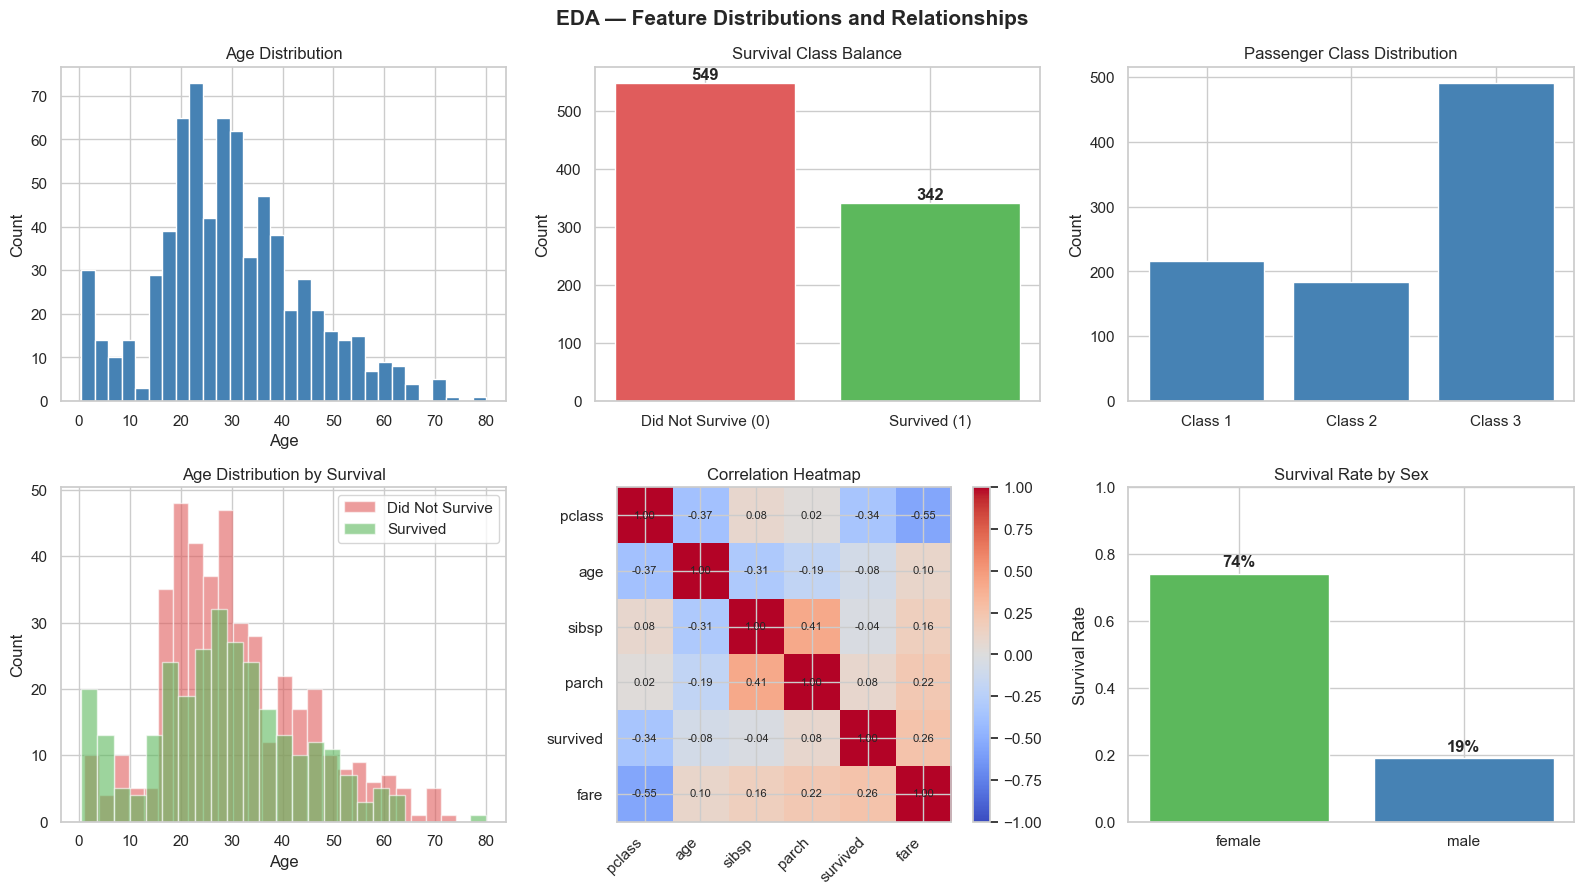

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Feature Distributions and Relationships", fontsize=15, fontweight="bold")

# 1. Age distribution
axes[0, 0].hist(X["age"].dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# 2. Survival countplot
counts = y_clf.value_counts().sort_index()
axes[0, 1].bar(["Did Not Survive (0)", "Survived (1)"], counts.values,
               color=["#e05c5c", "#5cb85c"], edgecolor="white")
axes[0, 1].set_title("Survival Class Balance")
axes[0, 1].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0, 1].text(i, v + 5, str(v), ha="center", fontweight="bold")

# 3. Passenger class countplot
pclass_counts = X["pclass"].value_counts().sort_index()
axes[0, 2].bar([f"Class {c}" for c in pclass_counts.index], pclass_counts.values,
               color="steelblue", edgecolor="white")
axes[0, 2].set_title("Passenger Class Distribution")
axes[0, 2].set_ylabel("Count")

# 4. Age by survival (overlapping histograms)
for survived, color, label in [(0, "#e05c5c", "Did Not Survive"), (1, "#5cb85c", "Survived")]:
    mask = y_clf == survived
    axes[1, 0].hist(X.loc[mask, "age"].dropna(), bins=25, alpha=0.6, color=color, label=label, edgecolor="white")
axes[1, 0].set_title("Age Distribution by Survival")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# 5. Correlation heatmap (numeric columns only)
corr = df[["pclass", "age", "sibsp", "parch", "survived", "fare"]].corr()
im = axes[1, 1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(corr.columns)))
axes[1, 1].set_yticks(range(len(corr.columns)))
axes[1, 1].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[1, 1].set_yticklabels(corr.columns)
axes[1, 1].set_title("Correlation Heatmap")
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[1, 1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[1, 1])

# 6. Survival rate by sex
surv_sex = df.groupby("sex")["survived"].mean()
axes[1, 2].bar(surv_sex.index, surv_sex.values, color=["#5cb85c", "steelblue"], edgecolor="white")
axes[1, 2].set_title("Survival Rate by Sex")
axes[1, 2].set_ylabel("Survival Rate")
axes[1, 2].set_ylim(0, 1)
for i, v in enumerate(surv_sex.values):
    axes[1, 2].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# **6) Missing Values: Detection and Handling**

## 6.1) df.isna() — See Missing Values (True / False)

The first step in any preprocessing workflow is to check where data is missing.
`isna()` scans every single cell in the DataFrame and returns `True` if the value is missing (NaN)
and `False` if it has data.

Think of it as a spotlight: it shows you exactly which cells are empty.

In [17]:
# isna() returns True for missing cells, False for present ones
# head(10) shows the first 10 rows so we can visually spot missing values

X.isna().head(10)

,pclass,age,sibsp,parch,sex,embarked,who,deck
0,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True
5,False,True,False,False,False,False,False,True
6,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,True
8,False,False,False,False,False,False,False,True
9,False,False,False,False,False,False,False,True


**Note:**

`isna()` does **not** modify the data — it simply creates a True/False map of where holes exist.

It is also commonly chained with other functions like `.sum()` to count missing values,
which we will see in the next step.

## 6.2) df.isna().sum() — Missing Values Per Column

After seeing *where* values are missing, we want to know *how many* are missing per column.
This helps you decide which columns need imputation and which are fine as-is.

In [18]:
# Count missing values in each column
# sum() treats True as 1 and False as 0, so it counts missing cells per column

X.isna().sum()

pclass        0
age         177
sibsp         0
parch         0
sex           0
embarked      2
who           0
deck        688
dtype: int64

### Visual: Missing Values per Column

A bar chart of missing value counts makes it immediately clear which columns
need the most attention, and which are clean.

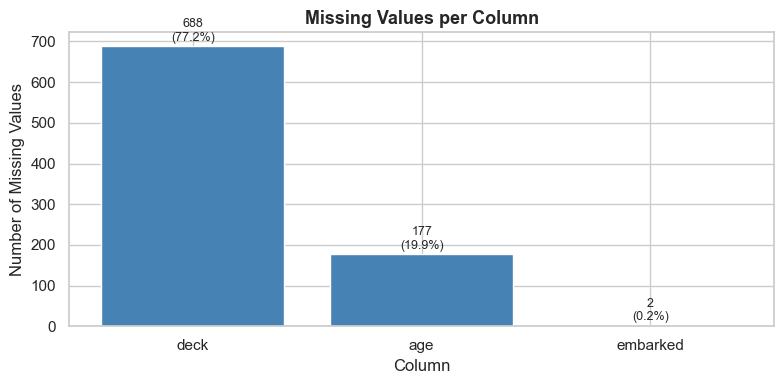

In [19]:
missing = X.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(missing.index, missing.values, color="steelblue", edgecolor="white")
ax.set_title("Missing Values per Column", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Missing Values")
ax.set_xlabel("Column")

# Add count + percentage labels on each bar
for bar, val in zip(bars, missing.values):
    pct = val / len(X) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

**Note:**

`isna().sum()` is one of the most commonly used preprocessing checks.

- A column with 0 missing values is clean
- A column with a few missing values → impute
- A column with a very high missing rate (like `deck` with 688/891) → consider dropping it entirely

This step guides your entire imputation strategy.

## 6.3) df.isna().sum(axis=1) — Missing Values Per Row

Sometimes a row is so incomplete that it is better to remove it entirely.
`sum(axis=1)` counts missing values horizontally across each row instead of down each column.

In [20]:
# Count missing values per row (per passenger)
# axis=1 means we sum across columns (row-wise)

X.isna().sum(axis=1).head(10)

0    1
1    0
2    1
3    0
4    1
5    2
6    0
7    1
8    1
9    1
dtype: int64

**Note:**

- `axis=0` (default) → sums down each column
- `axis=1` → sums across each row

A row with many missing values might not be useful for training.
You can keep only rows that have fewer than `threshold` missing values:
`df[df.isna().sum(axis=1) <= threshold]`

Or use pandas' built-in shortcut: `df.dropna(thresh=n)` — keeps rows with at least `n` non-missing values.

## 6.4) df.dropna() — Drop Rows With Any Missing Value

The simplest way to handle missing values: just remove any row that has at least one missing value.
This is safe and clean, but it can delete a large chunk of your data — use it carefully.

In [21]:
# Remove rows that have at least one missing value
X_drop_rows = X.dropna()

# Compare original vs cleaned shape
print("Original shape:", X.shape)
print("After dropna():", X_drop_rows.shape)
print("Rows removed:", X.shape[0] - X_drop_rows.shape[0])

Original shape: (891, 8)
After dropna(): (182, 8)
Rows removed: 709


**Note:**

`dropna()` without any arguments drops **any** row that has even a single missing value.

In our Titanic dataset, `deck` alone has 688 missing values out of 891 rows — using `dropna()` here
would remove most of our data! This is why blind `dropna()` is rarely the right choice in practice.

## 6.5) df.dropna(axis=1) — Drop Columns With Any Missing Value

Instead of removing rows, we can remove the entire column that contains missing values.
This preserves all rows but potentially removes useful features.

In [22]:
# Remove columns that have at least one missing value
X_drop_cols = X.dropna(axis=1)

print("Original shape:", X.shape)
print("After dropna(axis=1):", X_drop_cols.shape)
print("Remaining columns:", X_drop_cols.columns.tolist())

Original shape: (891, 8)
After dropna(axis=1): (891, 5)
Remaining columns: ['pclass', 'sibsp', 'parch', 'sex', 'who']


**Note:**

`axis=1` tells dropna to work column-wise instead of row-wise.

This dropped `age`, `embarked`, and `deck` — three potentially useful features.
That is the trade-off: simplicity vs information loss.

## 6.6) df.dropna(subset=[...]) — Drop Rows Only if Specific Columns Are Missing

A smarter approach: only remove a row if a **specific critical column** is missing.
Other missing values in less important columns are ignored for this decision.

In [23]:
# Drop rows only when the "embarked" column is missing (just 2 rows in this case)
X_drop_subset = X.dropna(subset=["embarked"])

print("Original shape:", X.shape)
print("After dropping rows where embarked is missing:", X_drop_subset.shape)

Original shape: (891, 8)
After dropping rows where embarked is missing: (889, 8)


**Note:**

`subset=["embarked"]` tells pandas: "Only check the `embarked` column when deciding whether to drop a row."

This is useful when you know a specific column is essential for your model
(e.g., you cannot encode `embarked` if it is missing), but other columns can be imputed.

## 6.7) df.fillna(value) — Fill All Missing Values With a Constant

The quickest way to fill every missing value in the entire DataFrame with one fixed value.
Commonly used for categorical columns where you want to explicitly label the unknown category.

In [24]:
# Fill all missing values with the string "Unknown"
X_fill_const = X.fillna("Unknown")

# Verify no missing values remain
X_fill_const.isna().sum()

pclass      0
age         0
sibsp       0
parch       0
sex         0
embarked    0
who         0
deck        0
dtype: int64

**Note:**

`fillna("Unknown")` works on every column at once. You can pass any value:
- A string like `"Unknown"` or `"Missing"` for categorical columns
- A number like `0` for numeric columns

After filling, `isna().sum()` should return all zeros.

## 6.8) df[col].fillna(df[col].mean()) — Mean Imputation (Single Column)

For numeric columns, replacing missing values with the column's **average** is a common quick fix.
It keeps the overall distribution roughly intact.

In [25]:
X_mean = X.copy()

# Replace missing values in "age" with the mean age of all known passengers
X_mean["age"] = X_mean["age"].fillna(X_mean["age"].mean())

print("Missing in age after mean imputation:", X_mean["age"].isna().sum())
print("Mean age used:", round(X["age"].mean(), 2))

Missing in age after mean imputation: 0
Mean age used: 29.7


**Note:**

When calculating the mean, `pandas` automatically **ignores NaN values** — so the average is computed
only from the passengers whose age we actually know.

Mean imputation works well when the data has no extreme outliers. If there are outliers,
the mean gets pulled toward them — in that case, **median imputation** is safer.

## 6.9) df[col].fillna(df[col].median()) — Median Imputation (Single Column)

The **median** is the middle value when you sort all values from smallest to largest.
It is not affected by extreme outliers the way the mean is, making it the safer choice for skewed data.

In [26]:
X_median = X.copy()

# Replace missing values in "age" with the median age
X_median["age"] = X_median["age"].fillna(X_median["age"].median())

print("Missing in age after median imputation:", X_median["age"].isna().sum())
print("Median age used:", X["age"].median())

Missing in age after median imputation: 0
Median age used: 28.0


**Note:**

For a column like `fare`, which has some extremely high values (up to 512), the **mean** would be
pulled upward by those outliers. The **median** ignores that and gives you the more typical middle value.

**Rule of thumb:** Use median when a column has outliers. Use mean when the distribution is roughly symmetric.

## 6.10) df[col].fillna(df[col].mode()[0]) — Mode Imputation (Single Column)

The **mode** is the most frequently occurring value. This is the standard choice for **categorical columns**
because you cannot calculate a mean or median on text labels.

In [27]:
X_mode = X.copy()

# Replace missing values in "embarked" with the most common embarkation port
X_mode["embarked"] = X_mode["embarked"].fillna(X_mode["embarked"].mode()[0])

print("Missing in embarked after mode imputation:", X_mode["embarked"].isna().sum())
print("Mode value used:", X["embarked"].mode()[0])

Missing in embarked after mode imputation: 0
Mode value used: S


**Note:**

`mode()` returns a pandas **Series** (a list of the most common values, in case of a tie).
We use `[0]` to extract just the first (most common) value from that list.

Mode imputation works well for categorical columns with a clearly dominant category.
For `embarked`, "S" (Southampton) is by far the most common port, so it is a reasonable fill value.

# **7) Handling Duplicates**

## 7.1) df.duplicated().sum() — Count Duplicate Rows

Duplicate rows are exact copies of other rows in the dataset. They can happen due to data entry errors,
data pipeline bugs, or when multiple sources are merged.

If duplicates are present during training, the model sees those examples more than once,
which can bias it toward those specific patterns.

In [28]:
# Check for duplicates in the full DataFrame df
# (we check df here — before the feature/target split — to catch all duplicates
#  including those that would only be visible when target columns are included)
print("Number of duplicate rows:", df.duplicated().sum())

# Show the duplicated rows — notice survived and fare columns are visible here
# because we are working with the full df, not just X
df[df.duplicated()].head()

Number of duplicate rows: 107


,survived,fare,pclass,age,sibsp,parch,sex,embarked,who,deck
47,1,7.7500,3,NaN,0,0,female,Q,woman,NaN
76,0,7.8958,3,NaN,0,0,male,S,man,NaN
77,0,8.0500,3,NaN,0,0,male,S,man,NaN
87,0,8.0500,3,NaN,0,0,male,S,man,NaN
95,0,8.0500,3,NaN,0,0,male,S,man,NaN


**Note:**

The Titanic dataset has **107 duplicate rows** — these are real duplicates in the raw seaborn version.

`duplicated()` marks the **second (and subsequent) occurrence** of a row as `True`,
while keeping the first occurrence as `False`.

## 7.2) df.drop_duplicates() — Remove Duplicate Rows

Once duplicates are identified, we remove them. `drop_duplicates()` keeps only the first occurrence
of each row and discards all exact copies.

In [29]:
df_no_dupes = df.drop_duplicates()

print("Original shape:", df.shape)
print("After removing duplicates:", df_no_dupes.shape)
print("Rows removed:", df.shape[0] - df_no_dupes.shape[0])

Original shape: (891, 10)
After removing duplicates: (784, 10)
Rows removed: 107


**Note:**

`drop_duplicates()` by default:
- Keeps the **first** occurrence of each duplicated row
- Removes all subsequent copies

You can change this with the `keep` parameter:
- `keep="first"` (default) → keep the first, drop the rest
- `keep="last"` → keep the last, drop the others
- `keep=False` → drop **all** copies of duplicated rows

In most preprocessing workflows, after removing duplicates, it is good practice to
reset the index (covered in Section 9).

# **8) Data Type Fixes and Text Cleaning**

## 8.1) Inspect Types with df.dtypes

Before doing any transformation, you need to know what type each column is stored as.
A column stored as `object` (string) when it should be `float64` (number) will break any
mathematical operation you try to apply to it.

In [30]:
# Show the data type of every column
df.dtypes

survived      int64
fare        float64
pclass        int64
age         float64
sibsp         int64
parch         int64
sex          object
embarked     object
who          object
deck         object
dtype: object

**Note:**

Common pandas data types:
- `int64` — whole numbers (no decimals)
- `float64` — decimal numbers (also used when a numeric column has NaN values)
- `object` — text / strings / mixed types
- `category` — a fixed set of known text labels
- `bool` — True or False values
- `datetime64` — date and time values

Always check dtypes after loading data. Numeric columns stored as `object` must be
converted before they can be scaled, imputed, or used in any model.

## 8.2) pd.to_numeric(..., errors="coerce") — Convert Messy Strings to Numbers

In real-world data, numeric values are often stored as strings — with units, currency symbols,
or other formatting characters mixed in. `pd.to_numeric()` converts them back to actual numbers.

`errors="coerce"` ensures that any value that cannot be converted simply becomes `NaN`
instead of crashing your program.

In [31]:
X_parse = X.copy()

# Teaching example: simulate messy data by converting age to a string with a suffix
X_parse["age_str"] = X_parse["age"].astype(str) + " yrs"

# Step 1: Remove the " yrs" suffix
# Step 2: Convert to numeric
X_parse["age_parsed"] = pd.to_numeric(
    X_parse["age_str"].str.replace(" yrs", "", regex=False),
    errors="coerce"
)

# Verify the conversion
X_parse[["age", "age_str", "age_parsed"]].head()

,age,age_str,age_parsed
0,22.0,22.0 yrs,22.0
1,38.0,38.0 yrs,38.0
2,26.0,26.0 yrs,26.0
3,35.0,35.0 yrs,35.0
4,35.0,35.0 yrs,35.0


**Note:**

The `errors` parameter controls what happens when a value cannot be converted:
- `errors="raise"` → throws an error immediately (default, but fragile)
- `errors="coerce"` → converts bad values to `NaN` (safe — handle them with imputation later)
- `errors="ignore"` → leaves the value unchanged as a string (rarely useful)

**Always use `errors="coerce"` in preprocessing** — it prevents crashes and lets you
handle the failed conversions later with imputation.

## 8.3) pd.to_datetime(...) — Parse Dates

Dates stored as strings or integers are useless for time-based analysis.
`pd.to_datetime()` converts them into proper datetime objects, from which you can extract
year, month, day, day-of-week, and many other features.

In [32]:
X_dates = X.copy()

# SYNTHETIC EXAMPLE ONLY — these dates are made up purely to demonstrate pd.to_datetime()
# In reality all Titanic passengers boarded on the same dates regardless of class
# pclass 1 → day 11, pclass 2 → day 12, pclass 3 → day 13  (10 + pclass)
X_dates["example_date"] = pd.to_datetime(
    "1912-04-" + (10 + X_dates["pclass"]).astype(str),
    errors="coerce"
)

# Once converted to datetime, you can extract components
X_dates["example_month"] = X_dates["example_date"].dt.month
X_dates["example_day"]   = X_dates["example_date"].dt.day

X_dates[["pclass", "example_date", "example_month", "example_day"]].head()

,pclass,example_date,example_month,example_day
0,3,1912-04-13,4,13
1,1,1912-04-11,4,11
2,3,1912-04-13,4,13
3,1,1912-04-11,4,11
4,3,1912-04-13,4,13


**Note:**

Once a column is a proper `datetime64`, you can extract many useful features using `.dt`:
- `.dt.year`, `.dt.month`, `.dt.day`
- `.dt.dayofweek` (0=Monday, 6=Sunday)
- `.dt.hour`, `.dt.minute`
- `.dt.quarter`

These extracted components can then be used as numeric features in your ML model.

## 8.4) astype("category") — Convert to Categorical Type

When a column has a small, fixed set of known labels (like `sex`, `embarked`, `who`),
converting it to `category` type tells pandas to treat it as a finite set of options
rather than arbitrary free-form text. This saves memory and signals intent clearly.

In [33]:
X_cat_type = X.copy()

# Convert "who" column to categorical type
X_cat_type["who"] = X_cat_type["who"].astype("category")

# Check the type and the known categories
print("dtype:", X_cat_type["who"].dtype)
print("categories:", X_cat_type["who"].cat.categories.tolist())

dtype: category
categories: ['child', 'man', 'woman']


**Note:**

Converting to `"category"` type:
- Saves memory (stores codes internally instead of repeating strings)
- Makes the set of valid values explicit
- **Does NOT** encode the column for ML — you still need `OneHotEncoder` or `LabelEncoder` before feeding it to a model

Think of it as a label — it marks the column's purpose, but doesn't transform the values.

## 8.5) .str.strip() — Remove Extra Spaces From Strings

Leading or trailing spaces in text columns create invisible duplicate categories.
For example, `"male"` and `"male "` (with a trailing space) look the same visually
but are treated as different values by pandas and any encoder.

In [34]:
X_strip = X.copy()

# Simulate messy data: add trailing spaces to the first 5 rows of "sex"
X_strip.loc[X_strip.index[:5], "sex"] = X_strip.loc[X_strip.index[:5], "sex"].astype(str) + "  "

# Show the problem: value_counts sees "male  " as a different category
print("Before strip:")
print(X_strip["sex"].value_counts())
print()

# Fix: strip whitespace from both ends
X_strip["sex"] = X_strip["sex"].astype(str).str.strip()

print("After strip:")
print(X_strip["sex"].value_counts())

Before strip:
sex
male        575
female      311
female        3
male          2
Name: count, dtype: int64

After strip:
sex
male      577
female    314
Name: count, dtype: int64


**Note:**

`.str.strip()` removes whitespace from **both ends** of each string.

Related methods:
- `.str.lstrip()` → remove only leading (left) spaces
- `.str.rstrip()` → remove only trailing (right) spaces

Always strip whitespace before encoding categorical columns — otherwise encoders will
create separate categories for padded and non-padded versions of the same label.

## 8.6) .str.lower() — Standardize Text to Lowercase

Inconsistent capitalization creates duplicate categories. `"Male"`, `"MALE"`, and `"male"`
are treated as three different values. Converting everything to lowercase makes them identical.

In [35]:
X_lower = X.copy()

# Simulate mixed-case data
X_lower.loc[X_lower.index[:3], "sex"] = "Male"
X_lower.loc[X_lower.index[3:6], "sex"] = "MALE"

print("Before lowercasing:")
print(X_lower["sex"].value_counts())
print()

# Standardize to lowercase
X_lower["sex"] = X_lower["sex"].astype(str).str.lower()

print("After lowercasing:")
print(X_lower["sex"].value_counts())

Before lowercasing:
sex
male      574
female    311
Male        3
MALE        3
Name: count, dtype: int64

After lowercasing:
sex
male      580
female    311
Name: count, dtype: int64


**Note:**

String standardization should always happen **before** encoding. The order matters:

1. Strip whitespace (`.str.strip()`)
2. Standardize case (`.str.lower()`)
3. Encode (OneHotEncoder, LabelEncoder, etc.)

If you encode first and then discover case inconsistencies, your encoding will be wrong.

## 8.7) Exception Handling During Data Cleaning

**What is an exception?**

When Python encounters an error during execution, it "raises an exception" — it stops what it is doing and reports the problem. Without any handling, this crashes your entire script.

A `try/except` block lets you say: *"Try this. If something goes wrong, do this instead of crashing."* This is essential when cleaning real-world data because you cannot always predict what bad values you will encounter.

Real-world data is messy and unpredictable. When running a cleaning step on a large dataset,
a single bad value can crash your entire script. Wrapping risky operations in a `try/except` block
lets your code handle errors gracefully instead of stopping completely.

In [36]:
# Simulate a column with mixed good and bad values
messy_ages = pd.Series(["22", "38", "not_a_number", "35", None, "27"])

cleaned_ages = []

for val in messy_ages:
    try:
        # Try to convert each value to a float
        cleaned_ages.append(float(val))
    except (ValueError, TypeError):
        # If conversion fails (e.g., "not_a_number" or None), store NaN instead
        cleaned_ages.append(np.nan)

result = pd.Series(cleaned_ages)
print("Cleaned ages:")
print(result)
print()
print("Missing after cleaning:", result.isna().sum())

Cleaned ages:
0    22.0
1    38.0
2     NaN
3    35.0
4     NaN
5    27.0
dtype: float64

Missing after cleaning: 2


**Note:**

The two most common exceptions when cleaning data:
- `ValueError` — the value exists but cannot be converted (e.g., `"not_a_number"`)
- `TypeError` — the value itself is an incompatible type (e.g., `None`)

In production data pipelines, exception handling is essential. You never know what
unexpected values will appear in real data.

**Tip:** For converting a whole column, `pd.to_numeric(series, errors="coerce")` does the same thing as this loop — but in one line and much faster. The manual `try/except` loop is useful when you need custom logic per row.

# **9) Index and Structure Management**

## 9.1) df.reset_index() — Reset the Row Index

Whenever you drop rows (e.g., after `dropna()` or `drop_duplicates()`), the row index
keeps its original numbers — it no longer runs from 0 to n-1. This can cause subtle bugs
when you try to align two DataFrames or use index-based operations.

`reset_index()` renumbers the rows cleanly from 0.

In [37]:
# Drop rows where "age" is missing — leaves 714 rows with non-consecutive index
X_dropped = X.dropna(subset=["age"])

# Show the first 5 index values — notice they are NOT 0,1,2,3,4
# because some early rows were dropped (e.g. row index 5 is missing age)
print("Index values (first 10):", X_dropped.index[:10].tolist())
print("Shape:", X_dropped.shape)
print()

# Reset the index so rows are numbered 0, 1, 2, ... cleanly
X_reset = X_dropped.reset_index(drop=True)

print("Index after reset (first 10):", X_reset.index[:10].tolist())
print("Now clean and consecutive — ready for indexing or merging.")

Index values (first 10): [0, 1, 2, 3, 4, 6, 7, 8, 9, 10]
Shape: (714, 8)

Index after reset (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Now clean and consecutive — ready for indexing or merging.


**Note:**

`drop=True` discards the old index (the original row numbers).
Without `drop=True`, the old index gets added as a new column called `"index"` — which is almost never what you want.

Always reset the index after:
- Dropping rows
- Filtering the DataFrame
- Splitting data
- Any operation that changes the row set

## 9.2) df.rename(columns={...}) — Rename Columns

Column names in raw data are often unclear, abbreviated, or inconsistent.
Renaming them makes your code more readable and your outputs more interpretable.

In [38]:
X_renamed = X.copy()

# Rename columns to clearer names
X_renamed = X_renamed.rename(columns={
    "pclass":   "passenger_class",
    "sibsp":    "siblings_spouses",
    "parch":    "parents_children",
    "embarked": "port_of_embarkation",
    "who":      "person_type"
})

print("Renamed columns:")
print(X_renamed.columns.tolist())

Renamed columns:
['passenger_class', 'age', 'siblings_spouses', 'parents_children', 'sex', 'port_of_embarkation', 'person_type', 'deck']


**Note:**

`rename(columns={old_name: new_name})` only renames the columns you specify — all others stay unchanged.

You can also rename all columns at once by setting `df.columns = [list of new names]`, but that
requires you to list every single column in the exact right order — error-prone for wide datasets.

## 9.3) Setting Column Headers Manually

Sometimes a dataset loads without proper column names, or you want to replace all headers at once.
You can assign a new list directly to `df.columns`.

In [39]:
# Create a small example without headers
sample = pd.DataFrame([
    [1, 22.0, "male"],
    [2, 38.0, "female"],
    [3, 26.0, "female"]
])

print("Before setting headers:")
print(sample.head())
print()

# Assign column names
sample.columns = ["passenger_class", "age", "sex"]

print("After setting headers:")
print(sample.head())

Before setting headers:
   0     1       2
0  1  22.0    male
1  2  38.0  female
2  3  26.0  female

After setting headers:
   passenger_class   age     sex
0                1  22.0    male
1                2  38.0  female
2                3  26.0  female


**Note:**

When loading a CSV without a header row, pandas assigns numeric column names (0, 1, 2...).
You can fix this either:
- At load time: `pd.read_csv("file.csv", header=None, names=["col1", "col2", ...])`
- After loading: `df.columns = [...]`

Make sure the length of the list matches the number of columns exactly — otherwise pandas raises an error.

## 9.4) Data Alignment and Consistency Checks

When working with multiple DataFrames (after splitting, merging, or reshaping), you need to verify
that columns and indices are aligned before running any operations. Misaligned data can produce
silent bugs that are very hard to trace.

In [40]:
# Split the dataset into two parts WITHOUT resetting index
# This preserves original indices so we can check for real overlap
X_part1 = X.iloc[:400].copy()
X_part2 = X.iloc[400:].copy()

print("Columns match:", X_part1.columns.tolist() == X_part2.columns.tolist())
print("Dtypes match:", (X_part1.dtypes == X_part2.dtypes).all())

# Check for overlapping indices — there should be none since they are sliced from different rows
overlap = set(X_part1.index).intersection(set(X_part2.index))
print("Index overlap:", overlap if overlap else "None — good!")

# Now reset both and re-check — after reset both start at 0, so they overlap
X_part1_reset = X_part1.reset_index(drop=True)
X_part2_reset = X_part2.reset_index(drop=True)
overlap_after = set(X_part1_reset.index).intersection(set(X_part2_reset.index))
print("Index overlap AFTER reset (expected — both start at 0):", len(overlap_after), "shared indices")
print("  -> After reset, both DataFrames have indices 0-N, so index values overlap.")
print("     This does not mean the rows match — never rely on index alignment")
print("     between two independently-reset DataFrames. Use pd.concat() or pd.merge() instead.")

# Reindex to enforce a specific column order
expected_cols = ["pclass", "age", "sibsp", "parch", "sex", "embarked", "who", "deck"]
X_aligned = X.reindex(columns=expected_cols)
print("\nReindexed column order:", X_aligned.columns.tolist())

Columns match: True
Dtypes match: True
Index overlap: None — good!
Index overlap AFTER reset (expected — both start at 0): 400 shared indices
  -> After reset, both DataFrames have indices 0-N, so index values overlap.
     This does not mean the rows match — never rely on index alignment
     between two independently-reset DataFrames. Use pd.concat() or pd.merge() instead.

Reindexed column order: ['pclass', 'age', 'sibsp', 'parch', 'sex', 'embarked', 'who', 'deck']


**Note:**

`df.reindex(columns=[...])` enforces a specific column order. Any columns not in the list are dropped,
and any listed columns that don't exist get added as `NaN`.

This is especially useful before feeding data into a trained pipeline — the column order at prediction
time must match the order used during training.

# **10) Z-Score Standardization (Manual)**

## 10.1) Manual Z-Score: (x - mean) / std

Z-score standardization transforms a numeric column so that:
- The **mean becomes 0**
- The **standard deviation becomes 1**

This puts all numeric features on the same scale. We use the `age` column to demonstrate
because it is numeric, has a clear real-world meaning, and is present in `X`.

The formula is: `z = (value - mean) / std`

In [41]:
# Select the "age" column for demonstration (numeric, in X)
col = "age"
x = X[col].dropna().astype(float)

# Manually compute z-score
mean = x.mean()
std  = x.std(ddof=0)   # ddof=0 = population standard deviation

z_manual = (x - mean) / std

print(f"Original age  — mean: {mean:.2f}, std: {std:.2f}")
print(f"Z-score       — mean: {z_manual.mean():.4f}, std: {z_manual.std(ddof=0):.4f}")
print()
z_manual.head()

Original age  — mean: 29.70, std: 14.52
Z-score       — mean: 0.0000, std: 1.0000



0   -0.530377
1    0.571831
2   -0.254825
3    0.365167
4    0.365167
Name: age, dtype: float64

**Note:**

`ddof=0` computes the **population** standard deviation (divides by N).
`ddof=1` (pandas default) computes the **sample** standard deviation (divides by N-1).

In plain terms: if you have *all* the data you will ever see (the whole "population"), use `ddof=0`. If you only have a *sample* of a larger dataset, use `ddof=1`. For ML preprocessing, we treat our training data as fixed, so `ddof=0` matches what `StandardScaler` uses internally.

**You generally won't use manual z-score in practice.** The `StandardScaler` below does this
automatically and integrates into sklearn pipelines.

### Visual: Before vs After Z-Score Standardization

The shape of the distribution stays exactly the same — only the scale on the x-axis changes.
Before: values in the range 0–80. After: values centred around 0 with std=1.

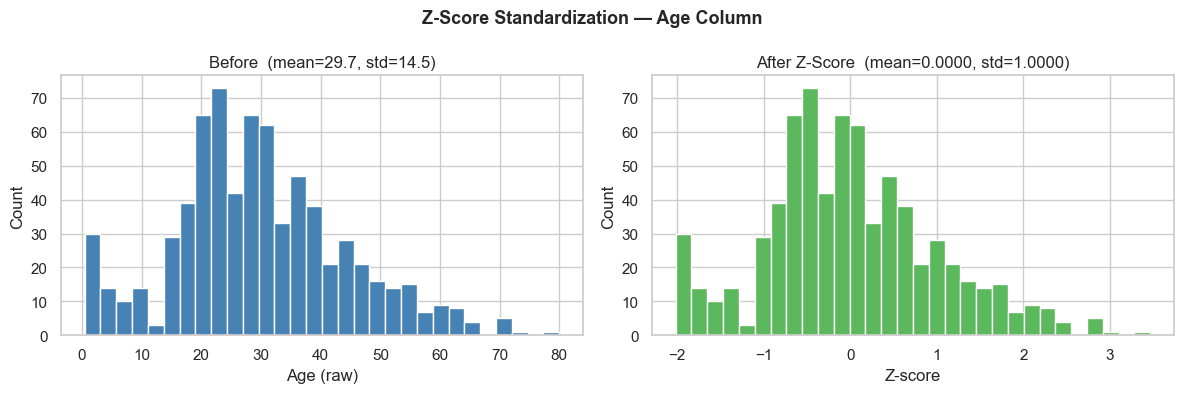

In [42]:
x_raw = X["age"].dropna().astype(float)
x_z   = (x_raw - x_raw.mean()) / x_raw.std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Z-Score Standardization — Age Column", fontsize=13, fontweight="bold")

axes[0].hist(x_raw, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title(f"Before  (mean={x_raw.mean():.1f}, std={x_raw.std(ddof=0):.1f})")
axes[0].set_xlabel("Age (raw)")
axes[0].set_ylabel("Count")

axes[1].hist(x_z, bins=30, color="#5cb85c", edgecolor="white")
axes[1].set_title(f"After Z-Score  (mean={x_z.mean():.4f}, std={x_z.std(ddof=0):.4f})")
axes[1].set_xlabel("Z-score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# **14) Data Reshaping**

## 14.1) df.T — Transposing a Dataset

Transposing flips a DataFrame: rows become columns and columns become rows.
It is rarely used on full ML datasets, but is very useful when you want to display
a summary table or compare a small number of samples side by side.

In [43]:
# Transpose a small slice of the dataset for easy visual comparison
X.head(5).T

,0,1,2,3,4
pclass,3,1,3,1,3
age,22.0,38.0,26.0,35.0,35.0
sibsp,1,1,0,1,0
parch,0,0,0,0,0
sex,male,female,female,female,male
embarked,S,C,S,S,S
who,man,woman,woman,woman,man
deck,NaN,C,NaN,C,NaN


**Note:**

`df.T` is shorthand for `df.transpose()`.

For a DataFrame with shape (5, 8), the transpose has shape (8, 5) — 8 rows and 5 columns.

In ML preprocessing, transposing is useful when:
- You want to look at a few samples as "feature profiles"
- You are working with time-series data where time flows along rows
- You need to feed data to a model expecting a different orientation

## 14.2) Wide to Long Format — pd.melt()

Many datasets come in **wide format**: each variable is a separate column.
**Long format** puts all variable names in one column and all values in another.

Long format is required by many statistical models and visualization libraries (like seaborn's `lineplot`).

In [44]:
# Build a summary pivot table: survival rate by passenger class and sex
# This is naturally in wide format
wide_df = df.groupby(["pclass", "sex"])["survived"].mean().unstack()
wide_df = wide_df.reset_index()
wide_df.columns.name = None

print("Wide format (one column per sex):")
print(wide_df)
print()

# Convert from wide to long format using melt
long_df = pd.melt(
    wide_df,
    id_vars=["pclass"],      # Column(s) to keep as-is (the identifier)
    value_vars=["female", "male"],  # Columns to unpivot
    var_name="sex",          # Name for the new variable column
    value_name="survival_rate"  # Name for the new value column
)

print("Long format (one row per pclass-sex combination):")
print(long_df)

Wide format (one column per sex):
   pclass    female      male
0       1  0.968085  0.368852
1       2  0.921053  0.157407
2       3  0.500000  0.135447

Long format (one row per pclass-sex combination):
   pclass     sex  survival_rate
0       1  female       0.968085
1       2  female       0.921053
2       3  female       0.500000
3       1    male       0.368852
4       2    male       0.157407
5       3    male       0.135447


**Note:**

**Wide format:** Each category gets its own column.
- Easy to read for humans
- Hard for many ML/stats functions

**Long format:** One row per observation, one column for the variable name, one for the value.
- More flexible for analysis and plotting
- Required by many seaborn and statsmodels functions

`pd.melt()` always goes **wide → long**. To go the other way, use `pd.pivot()`.

### Visual: Survival Rate by Passenger Class and Sex

The long-format DataFrame is perfect for grouped bar charts.
This plot shows the same data we just reshaped — now visualized.

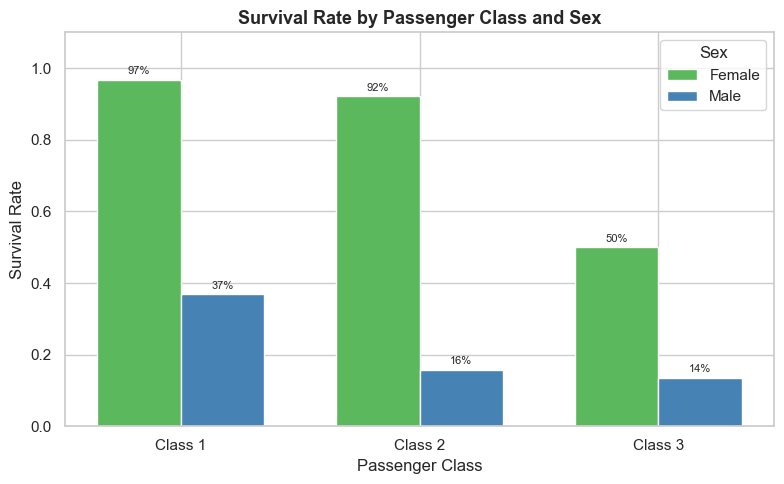

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))

classes = long_df["pclass"].unique()
sexes   = long_df["sex"].unique()
x       = range(len(classes))
width   = 0.35
colors  = {"female": "#5cb85c", "male": "steelblue"}

for i, sex in enumerate(sexes):
    subset = long_df[long_df["sex"] == sex].sort_values("pclass")
    offset = (i - 0.5) * width
    bars = ax.bar([xi + offset for xi in x], subset["survival_rate"].values,
                  width=width, label=sex.capitalize(), color=colors[sex], edgecolor="white")
    for bar, val in zip(bars, subset["survival_rate"].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.0%}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels([f"Class {c}" for c in sorted(classes)])
ax.set_title("Survival Rate by Passenger Class and Sex", fontsize=13, fontweight="bold")
ax.set_ylabel("Survival Rate")
ax.set_xlabel("Passenger Class")
ax.set_ylim(0, 1.1)
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

## 14.3) Long to Wide Format — df.pivot() and df.unstack()

`pivot()` restructures a long DataFrame into wide format by spreading values across columns.
`unstack()` does something similar but works on multi-level (hierarchical) indices.

In [46]:
# Go back from long to wide using pivot
wide_again = long_df.pivot(
    index="pclass",       # Row identifier
    columns="sex",        # Column to spread out as new columns
    values="survival_rate"  # Values to fill in the cells
)

print("Back to wide format using pivot():")
print(wide_again)
print()

# Alternative: unstack() on a grouped result
survival_by_class_sex = df.groupby(["pclass", "sex"])["survived"].mean()
print("Multi-index Series before unstack:")
print(survival_by_class_sex)
print()
print("After unstack (sex becomes columns):")
print(survival_by_class_sex.unstack())

Back to wide format using pivot():
sex       female      male
pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447

Multi-index Series before unstack:
pclass  sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64

After unstack (sex becomes columns):
sex       female      male
pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


**Note:**

`pivot()` requires:
- `index` — the column whose values become the row labels
- `columns` — the column whose values become the new column headers
- `values` — the column containing the data to fill in

If there are duplicate combinations of (index, columns), `pivot()` raises an error.
In that case, use `pivot_table()` which can aggregate duplicates.

## 14.4) Concatenation — pd.concat()

Concatenation joins two or more DataFrames together — either stacking them vertically
(adding more rows) or horizontally (adding more columns).

In [47]:
# Split the dataset in half
df_part1 = X.iloc[:446].copy().reset_index(drop=True)
df_part2 = X.iloc[446:].copy().reset_index(drop=True)

print("Part 1 shape:", df_part1.shape)
print("Part 2 shape:", df_part2.shape)
print()

# Stack them back together vertically (axis=0 = add rows)
df_concat = pd.concat([df_part1, df_part2], axis=0, ignore_index=True)

print("Concatenated shape:", df_concat.shape)
print()

# Horizontal concatenation: join two sets of columns side by side
df_left  = X[["pclass", "age", "sibsp"]].reset_index(drop=True)
df_right = X[["sex", "embarked", "who"]].reset_index(drop=True)

df_hconcat = pd.concat([df_left, df_right], axis=1)
print("Horizontal concat shape:", df_hconcat.shape)
df_hconcat.head()

Part 1 shape: (446, 8)
Part 2 shape: (445, 8)

Concatenated shape: (891, 8)

Horizontal concat shape: (891, 6)


,pclass,age,sibsp,sex,embarked,who
0,3,22.0,1,male,S,man
1,1,38.0,1,female,C,woman
2,3,26.0,0,female,S,woman
3,1,35.0,1,female,S,woman
4,3,35.0,0,male,S,man


**Note:**

`axis=0` → stack rows (default)
`axis=1` → stack columns side by side

`ignore_index=True` resets the index after vertical concatenation — otherwise the
index from each piece is preserved, which can create duplicate index values.

Common use cases:
- Combining train and test for **column selection or format conversion only** — never fit transformers (scalers, imputers, encoders) on combined data, as this causes data leakage
- Adding new batches of data to an existing dataset
- Assembling a feature matrix from multiple sources

## 14.5) Merging / Joining Datasets — pd.merge()

In real projects, data often lives in multiple tables. `pd.merge()` combines two DataFrames
based on a shared key column — just like a SQL JOIN.

This is one of the most important data manipulation operations in practice.

In [48]:
# Simulate two separate tables from the Titanic dataset
# Table 1: Passenger demographic info
passenger_info = df[["pclass", "age", "sex", "fare"]].copy().reset_index()
passenger_info = passenger_info.rename(columns={"index": "passenger_id"})

# Table 2: Survival outcome
survival_info = df[["survived"]].copy().reset_index()
survival_info = survival_info.rename(columns={"index": "passenger_id"})

print("passenger_info shape:", passenger_info.shape)
print("survival_info shape: ", survival_info.shape)
print()

# Merge on the shared key "passenger_id"
merged = pd.merge(
    passenger_info,
    survival_info,
    on="passenger_id",   # The column that links the two tables
    how="inner"          # Keep only rows where passenger_id exists in BOTH tables
)

print("Merged shape:", merged.shape)
merged.head()

passenger_info shape: (891, 5)
survival_info shape:  (891, 2)

Merged shape: (891, 6)


,passenger_id,pclass,age,sex,fare,survived
0,0,3,22.0,male,7.2500,0
1,1,1,38.0,female,71.2833,1
2,2,3,26.0,female,7.9250,1
3,3,1,35.0,female,53.1000,1
4,4,3,35.0,male,8.0500,0


**Note:**

The `how` parameter controls which rows to keep:

| Join type | What it keeps |
|---|---|
| `inner` | Only rows where the key exists in **both** tables |
| `left` | All rows from the **left** table, matching rows from the right |
| `right` | All rows from the **right** table, matching rows from the left |
| `outer` | All rows from **both** tables, filling missing matches with NaN |

`inner` join is the most common default. Use `left` join when the left table is the "master"
and you don't want to lose any of its records.

# **15) Feature Engineering**

## 15.1) Creating New Features

Feature engineering is the process of creating **new, informative columns** from existing ones.
A well-engineered feature can dramatically improve model performance because it gives the model
information it would otherwise have to figure out on its own through complex combinations.

The goal is to encode **domain knowledge** directly into the data.

In [49]:
X_eng = X.copy()

# 1. Family size: total family members aboard (including the passenger)
X_eng["family_size"] = X_eng["sibsp"] + X_eng["parch"] + 1

# 2. Is alone: binary flag for passengers travelling solo
# (X_eng["family_size"] == 1) produces True/False for each row
# .astype(int) converts True → 1 and False → 0 for clean, explicit numeric representation
X_eng["is_alone"] = (X_eng["family_size"] == 1).astype(int)

# 3. Age x Class: interaction feature combining age and passenger class
#    Missing age values are filled with the median ONLY for computing this feature
#    (the age column in X_eng itself is left unchanged — NaN values remain there)
X_eng["age_x_class"] = X_eng["age"].fillna(X_eng["age"].median()) * X_eng["pclass"]

print("New features created:")
X_eng[["sibsp", "parch", "age", "pclass", "family_size", "is_alone", "age_x_class"]].head(10)

New features created:


,sibsp,parch,age,pclass,family_size,is_alone,age_x_class
0,1,0,22.0,3,2,0,66.0
1,1,0,38.0,1,2,0,38.0
2,0,0,26.0,3,1,1,78.0
3,1,0,35.0,1,2,0,35.0
4,0,0,35.0,3,1,1,105.0
5,0,0,NaN,3,1,1,84.0
6,0,0,54.0,1,1,1,54.0
7,3,1,2.0,3,5,0,6.0
8,0,2,27.0,3,3,0,81.0
9,1,0,14.0,2,2,0,28.0


**Note:**

Good feature engineering is based on **domain understanding**:
- `family_size` captures a social factor: large families may have behaved differently during evacuation
- `is_alone` is a clear binary signal that is easier for a model to use than parsing family_size
- `age_x_class` combines age and passenger class into one interaction feature — capturing that a young 3rd-class passenger and an old 1st-class passenger had very different survival odds

Feature engineering is one of the highest-leverage activities in the ML workflow.
A good feature can matter more than the choice of model.

### Visual: Engineered Features — Family Size and Is Alone

Visualizing engineered features confirms they capture meaningful signal.
The survival rate by family size and the alone/not-alone split are both clearly visible.

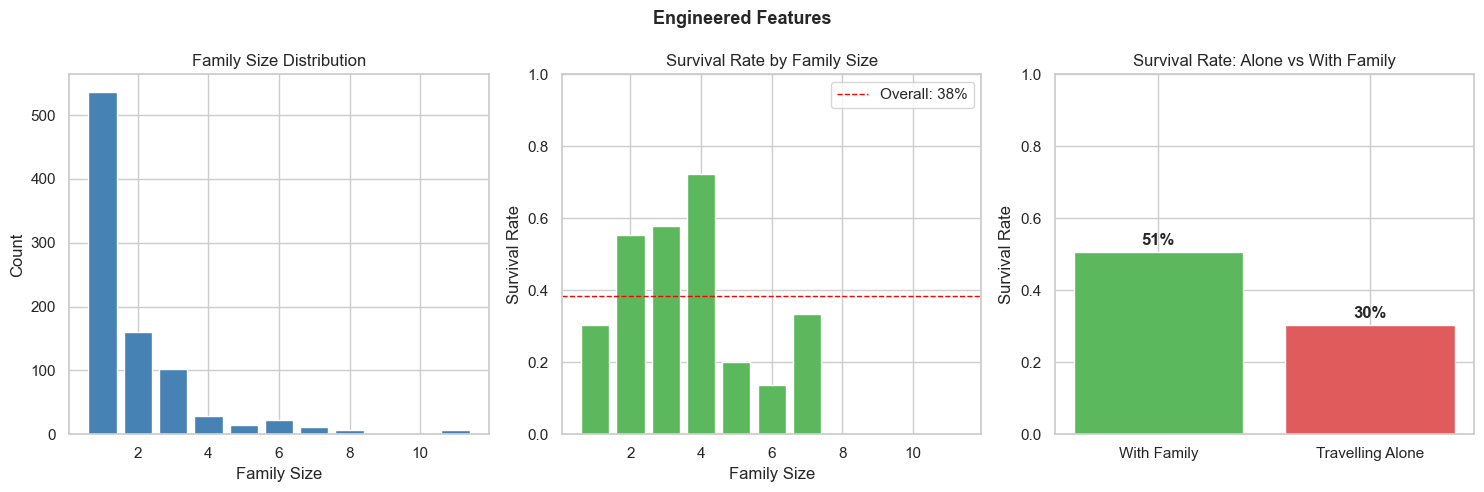

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Engineered Features", fontsize=13, fontweight="bold")

# 1. Family size distribution
X_eng_plot = X_eng.copy()
X_eng_plot["survived"] = y_clf.values

fs_counts = X_eng_plot["family_size"].value_counts().sort_index()
axes[0].bar(fs_counts.index, fs_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Family Size Distribution")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Count")

# 2. Survival rate by family size
surv_by_fs = X_eng_plot.groupby("family_size")["survived"].mean()
axes[1].bar(surv_by_fs.index, surv_by_fs.values, color="#5cb85c", edgecolor="white")
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Survival Rate")
axes[1].set_ylim(0, 1)
axes[1].axhline(y_clf.mean(), color="red", linestyle="--", linewidth=1, label=f"Overall: {y_clf.mean():.0%}")
axes[1].legend()

# 3. Is alone vs not alone survival rate
alone_surv = X_eng_plot.groupby("is_alone")["survived"].mean()
labels = ["With Family", "Travelling Alone"]
bars = axes[2].bar(labels, alone_surv.values, color=["#5cb85c", "#e05c5c"], edgecolor="white")
axes[2].set_title("Survival Rate: Alone vs With Family")
axes[2].set_ylabel("Survival Rate")
axes[2].set_ylim(0, 1)
for bar, val in zip(bars, alone_surv.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 15.2) Binning — pd.cut() and pd.qcut()

**Binning** groups a continuous numeric column into discrete categories (buckets).
This can make a model more robust to outliers and can capture non-linear relationships
that a simple numeric value might miss.

`pd.cut()` creates bins of equal **width** (you define the edges).
`pd.qcut()` creates bins of equal **frequency** (equal number of rows per bin).

We use the `age` column throughout — it is numeric, has real-world meaning, and lives in `X`.

In [51]:
X_binned = X.copy()

# --- pd.cut(): Fixed-width bins based on domain knowledge ---
# Age groups with meaningful real-world labels
X_binned["age_group"] = pd.cut(
    X_binned["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["child", "teen", "young_adult", "adult", "senior"],
    right=True    # Bins are (left, right] — left exclusive, right inclusive
)

# --- pd.qcut(): Equal-frequency bins ---
# Passenger class is already ordinal (1/2/3), so we bin age into quartiles instead
X_binned["age_quartile"] = pd.qcut(
    X_binned["age"].fillna(X_binned["age"].median()),
    q=4,
    labels=["youngest", "young", "mature", "oldest"]
)

X_binned[["age", "age_group", "age_quartile"]].head(15)

,age,age_group,age_quartile
0,22.0,young_adult,youngest
1,38.0,adult,oldest
2,26.0,young_adult,young
3,35.0,young_adult,mature
4,35.0,young_adult,mature
5,NaN,NaN,young
6,54.0,adult,oldest
7,2.0,child,youngest
8,27.0,young_adult,young
9,14.0,teen,youngest


**Note:**

| | `pd.cut()` | `pd.qcut()` |
|---|---|---|
| Bin edges | You define them | Computed automatically |
| Bin width | Equal width | Unequal width |
| Bin frequency | Unequal | Equal |
| Use when | You have domain knowledge about thresholds | You want equal representation in each bin |

After binning, the new column is **categorical** and will need to be encoded
(OneHotEncoder or OrdinalEncoder) before being used in a model.

### Visual: Age Groups and Age Quartiles

Bar charts of binned columns show how the data distributes across buckets
and let you verify the bins are meaningful and not empty.

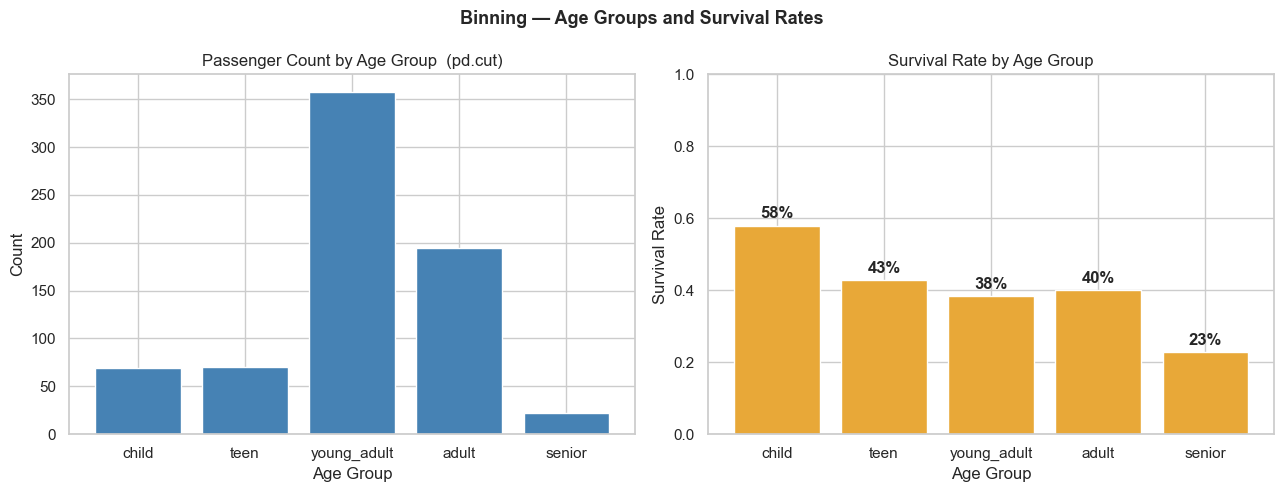

In [52]:
X_binned_plot = X_binned.copy()
X_binned_plot["survived"] = y_clf.values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Binning — Age Groups and Survival Rates", fontsize=13, fontweight="bold")

# 1. Count per age group
age_grp = X_binned_plot["age_group"].value_counts()
# keep label order
order = ["child", "teen", "young_adult", "adult", "senior"]
age_grp = age_grp.reindex([o for o in order if o in age_grp.index])
axes[0].bar(age_grp.index, age_grp.values, color="steelblue", edgecolor="white")
axes[0].set_title("Passenger Count by Age Group  (pd.cut)")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")

# 2. Survival rate per age group
surv_by_grp = X_binned_plot.groupby("age_group", observed=True)["survived"].mean()
surv_by_grp = surv_by_grp.reindex([o for o in order if o in surv_by_grp.index])
bars = axes[1].bar(surv_by_grp.index, surv_by_grp.values, color="#e8a838", edgecolor="white")
axes[1].set_title("Survival Rate by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Survival Rate")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, surv_by_grp.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# **19) Converting Between NumPy and Pandas**

## 19.1) DataFrame to NumPy Array

Many scikit-learn functions accept DataFrames but return NumPy arrays.
Understanding how to move between these two formats fluently is an essential skill.

**Why does sklearn return NumPy arrays instead of DataFrames?**

Scikit-learn was built before pandas became widely used in machine learning. It was designed to work with pure NumPy arrays — fast, compact grids of numbers. This is why every `fit_transform()` call strips away column names and returns a plain array. Wrapping the result in `pd.DataFrame()` gives you the column names back.

In [53]:
# Method 1: .to_numpy() — recommended modern approach
arr1 = X[num_cols].fillna(0).to_numpy()
print("Type after .to_numpy():", type(arr1))
print("Shape:", arr1.shape)
print("First row:", arr1[0])
print()

# Method 2: .values — older approach, still widely seen in code
arr2 = X[num_cols].fillna(0).values
print("Type after .values:   ", type(arr2))
print("Shape:", arr2.shape)

Type after .to_numpy(): <class 'numpy.ndarray'>
Shape: (891, 4)
First row: [ 3. 22.  1.  0.]

Type after .values:    <class 'numpy.ndarray'>
Shape: (891, 4)


## 19.2) NumPy Array to DataFrame

After applying sklearn transformers (which return NumPy arrays), converting back to a DataFrame
restores column names and makes results human-readable and compatible with pandas operations.

In [54]:
# sklearn transformers return NumPy arrays — convert back to DataFrame
imp = SimpleImputer(strategy="median")
arr = imp.fit_transform(X[num_cols])

# Method: pd.DataFrame(array, columns=column_names)
df_from_array = pd.DataFrame(arr, columns=num_cols)

print("Type:", type(df_from_array))
print("Shape:", df_from_array.shape)
df_from_array.head()

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (891, 4)


,pclass,age,sibsp,parch
0,3.0,22.0,1.0,0.0
1,1.0,38.0,1.0,0.0
2,3.0,26.0,0.0,0.0
3,1.0,35.0,1.0,0.0
4,3.0,35.0,0.0,0.0


**Note:**

| Operation | Code |
|---|---|
| DataFrame → NumPy | `df.to_numpy()` or `df.values` |
| NumPy → DataFrame | `pd.DataFrame(arr, columns=[...])` |
| Get values as list | `df["col"].tolist()` |
| Get index as array | `df.index.to_numpy()` |

`.to_numpy()` is the preferred modern approach over `.values` because it is more explicit
and supports additional options like specifying the dtype.

After any sklearn `fit_transform()` call, always wrap the result in `pd.DataFrame()` if
you need to continue working with it in pandas (filtering, grouping, joining, etc.).